# Parashikimi i Klinikes me te Afert nga merged.csv me K-Nearest Neighbors (KNN)

Perdorimi i datasetit `merged.csv`  i cili eshte nje dataset i bashkuar i cili perfshin klinika nga Kosova dhe Shqiperia, per te gjetur klinikat dermatologjike me te aferta nga nje lokacion i dhene nga perdoruesi.

Meqenese dataseti nuk ka etiketa klasifikimi, ketu perdorim algoritmin **K-Nearest Neighbors** si model per kerkim te fqinjeve me te afert (`NearestNeighbors`). Modeli trajnohet me koordinatat gjeografike (`latitude`, `longitude`) dhe perdor distancen **haversine**.

### 1. Importimi i Bibliotekave

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_colwidth", 120)

### 2. Percaktimi i Folderave

In [3]:
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "merged.csv")
MODEL_PATH = os.path.join(BASE_DIR, "clinic_knn_2_model.pkl")
DATA_CLEAN_PATH = os.path.join(BASE_DIR, "clinic_knn_2_clean_data.pkl")

print("Base directory:", BASE_DIR)
print("Dataset path:", DATA_PATH)

Base directory: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset
Dataset path: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset\merged.csv


### 3. Ngarkimi dhe Kontrolli Fillestar i Datasetit

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Numri total i klinikave: {len(df)}")
print("Dimensioni i datasetit:", df.shape)
print("\nKolonat:")
print(df.columns.tolist())

df.head()

Numri total i klinikave: 124
Dimensioni i datasetit: (124, 11)

Kolonat:
['name', 'address', 'website', 'phone_number', 'reviews_count', 'reviews_average', 'latitude', 'longitude', 'category', 'location', 'source_file']


,name,address,website,phone_number,reviews_count,reviews_average,latitude,longitude,category,location,source_file
0,Derma Line Klinika Dermatologjike & Estetike,"Arberi, Rr.Vicianum nr 186/7, Prishtinë 10000",NaN,+383 45 100 450,48.0,4.9,42.659687,21.149412,dermatologist,Albania,dermatologist_in_Albania.csv
1,Swiss Eco Clinic,"Fortuzi, Tiranë, Albania",https://www.swissecoclinic.com/,+355 67 743 3696,97.0,4.9,41.332607,19.815196,dermatologist,Albania,dermatologist_in_Albania.csv
2,Skin Tech Derma Center,"Seksion B, Kati i 4, Tirana Ring Center, Zogu i Zi, Tiranë 1000, Albania",NaN,+355 4 242 1413,63.0,4.9,41.332682,19.803584,dermatologist,Albania,dermatologist_in_Albania.csv
3,Derma Pure Aesthetic,"Rr. Skenderbeu, Fier 9301, Albania",https://instagram.com/dermapure_aesthetic/,+355 69 491 8550,141.0,5.0,40.734750,19.562275,dermatologist,Albania,dermatologist_in_Albania.csv
4,"Klinika Dermatologjike ""A-Derma""","Rruga Don Bosko Ndertesa 3, Hyrja 24, Apartamenti 6, Tiranë 1026, Albania",http://www.aderma.al/,+355 4 240 4060,253.0,4.1,41.335195,19.805310,dermatologist,Albania,dermatologist_in_Albania.csv


In [5]:
print("Informacion mbi datasetin:")
df.info()

print("\nVlerat qe mungojne per cdo kolone:")
print(df.isna().sum())

Informacion mbi datasetin:
<class 'pandas.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             124 non-null    str    
 1   address          123 non-null    str    
 2   website          58 non-null     str    
 3   phone_number     110 non-null    str    
 4   reviews_count    120 non-null    float64
 5   reviews_average  115 non-null    float64
 6   latitude         124 non-null    float64
 7   longitude        124 non-null    float64
 8   category         124 non-null    str    
 9   location         124 non-null    str    
 10  source_file      124 non-null    str    
dtypes: float64(4), str(7)
memory usage: 10.8 KB

Vlerat qe mungojne per cdo kolone:
name                0
address             1
website            66
phone_number       14
reviews_count       4
reviews_average     9
latitude            0
longitude           0
category            

### 4. Pastrimi i te Dhenave

Per KNN ne kete rast duhen patjeter koordinatat. Rreshtat pa `latitude` ose `longitude` hiqen.

In [6]:
clinic_df = df.copy()

clinic_df["reviews_count"] = clinic_df["reviews_count"].fillna(0)
clinic_df["reviews_average"] = clinic_df["reviews_average"].fillna(clinic_df["reviews_average"].median())
clinic_df["website"] = clinic_df["website"].fillna("Nuk ka website")
clinic_df["phone_number"] = clinic_df["phone_number"].fillna("Nuk ka numer")

clinic_df = clinic_df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
clinic_df["clinic_id"] = clinic_df.index

print(f"Klinika te vlefshme per KNN: {len(clinic_df)}")
clinic_df[["clinic_id", "name", "reviews_average", "reviews_count", "latitude", "longitude"]].head()

Klinika te vlefshme per KNN: 124


,clinic_id,name,reviews_average,reviews_count,latitude,longitude
0,0,Derma Line Klinika Dermatologjike & Estetike,4.9,48.0,42.659687,21.149412
1,1,Swiss Eco Clinic,4.9,97.0,41.332607,19.815196
2,2,Skin Tech Derma Center,4.9,63.0,41.332682,19.803584
3,3,Derma Pure Aesthetic,5.0,141.0,40.734750,19.562275
4,4,"Klinika Dermatologjike ""A-Derma""",4.1,253.0,41.335195,19.805310


### 5. Matrica e Korelacionit

Kjo matrice tregon lidhjen mes variablave numerike te datasetit. Vlerat afer `1` tregojne korelacion pozitiv, vlerat afer `-1` korelacion negativ, ndersa vlerat afer `0` tregojne pak ose aspak lidhje lineare.


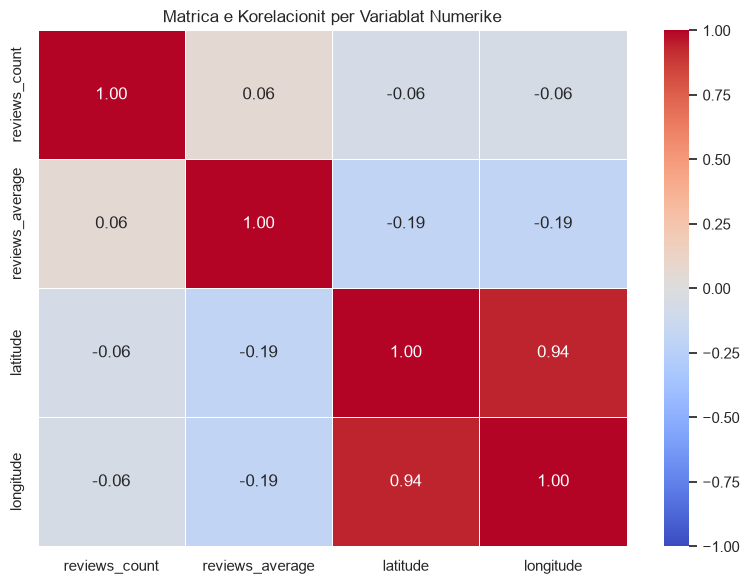

In [7]:
numeric_cols = ["reviews_count", "reviews_average", "latitude", "longitude"]
corr_matrix = clinic_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Matrica e Korelacionit per Variablat Numerike")
plt.tight_layout()
plt.show()


### 6. Vizualizimi i Lokacioneve te Klinikave

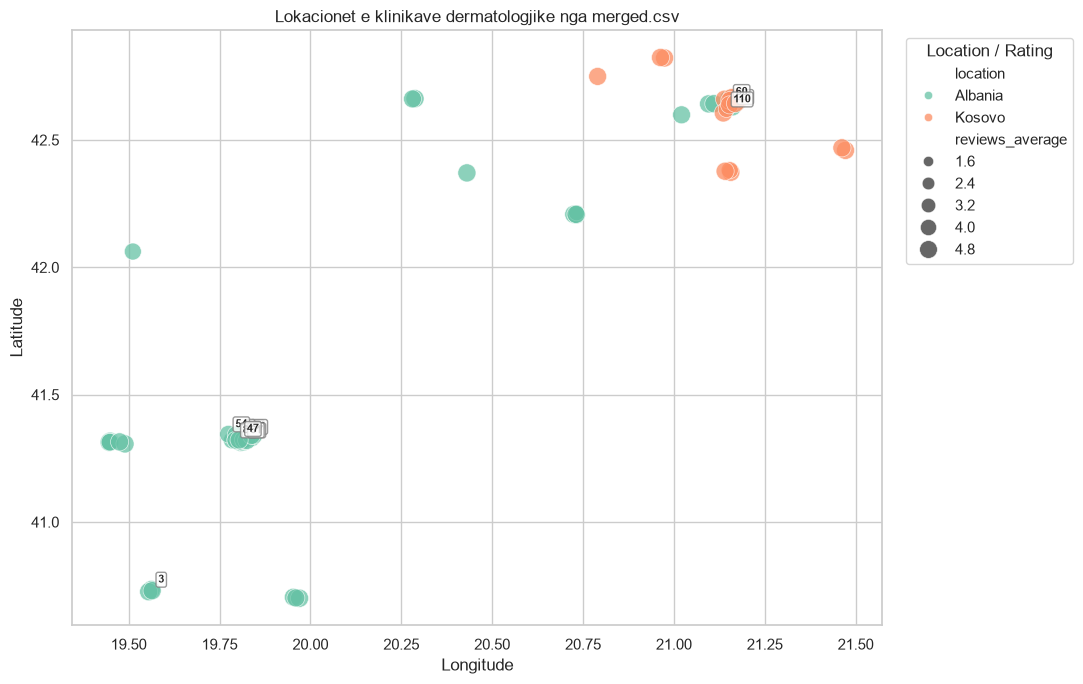

ID-te e etiketuara ne harte jane Top 15 klinikat sipas numrit te reviews.


,clinic_id,name,location,reviews_count,reviews_average
71,71,estethica,Albania,1206.0,5.0
5,5,Klinika Estetike Dermolife - Kirurgjia Italiane,Albania,649.0,4.6
50,50,Advanced Hair Transplant Clinic,Albania,632.0,4.9
49,49,Hair Solution Clinic Albania,Albania,596.0,5.0
4,4,"Klinika Dermatologjike ""A-Derma""",Albania,253.0,4.1
42,42,Klinika Grande,Albania,223.0,4.8
9,9,Klinika Dermaplus,Albania,192.0,4.8
60,60,Kirurgjia estetike italiane Prishtine - DaVINCI,Albania,173.0,4.9
54,54,Anassa,Albania,168.0,4.7
87,87,International Hair Clinic - Hair Transplant - Eyebrow Transplant,Albania,146.0,4.9


In [8]:
plt.figure(figsize=(11, 7))
top_reviewed = clinic_df.sort_values("reviews_count", ascending=False).head(15)

sns.scatterplot(
    data=clinic_df,
    x="longitude",
    y="latitude",
    hue="location",
    size="reviews_average",
    sizes=(35, 170),
    alpha=0.75,
    palette="Set2",
    edgecolor="white",
    linewidth=0.5,
)

for _, row in top_reviewed.iterrows():
    plt.annotate(
        str(row["clinic_id"]),
        xy=(row["longitude"], row["latitude"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8),
    )

plt.title("Lokacionet e klinikave dermatologjike nga merged.csv")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Location / Rating", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

print("ID-te e etiketuara ne harte jane Top 15 klinikat sipas numrit te reviews.")
display(top_reviewed[["clinic_id", "name", "location", "reviews_count", "reviews_average"]])


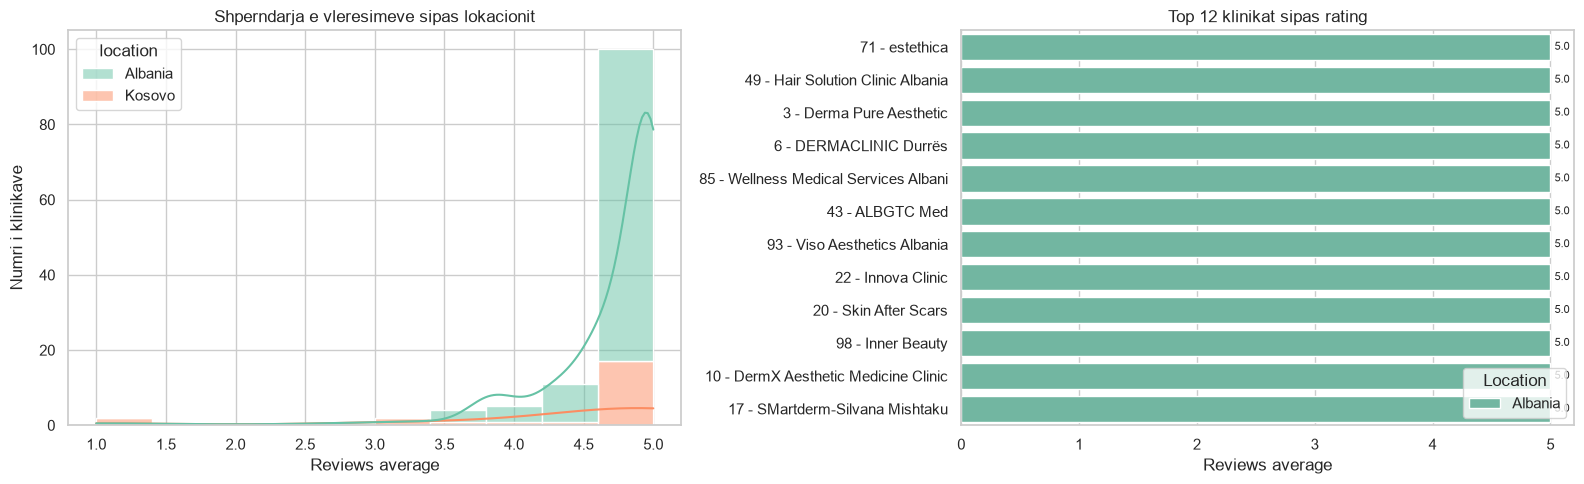

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(
    data=clinic_df,
    x="reviews_average",
    hue="location",
    bins=10,
    kde=True,
    multiple="stack",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Shperndarja e vleresimeve sipas lokacionit")
axes[0].set_xlabel("Reviews average")
axes[0].set_ylabel("Numri i klinikave")

rating_order = clinic_df.sort_values(["reviews_average", "reviews_count"], ascending=False).head(12).copy()
rating_order["label"] = rating_order["clinic_id"].astype(str) + " - " + rating_order["name"].str.slice(0, 32)

sns.barplot(
    data=rating_order,
    y="label",
    x="reviews_average",
    hue="location",
    dodge=False,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Top 12 klinikat sipas rating")
axes[1].set_xlabel("Reviews average")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 5.2)
axes[1].legend(title="Location", loc="lower right")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


### 7. Pergatitja e Karakteristikave per KNN

`NearestNeighbors` me metric `haversine` pret koordinatat ne radiane. Distancat qe kthen modeli jane ne radiane, prandaj i shumezojme me rrezen mesatare te Tokes per t'i kthyer ne kilometra.

In [10]:
EARTH_RADIUS_KM = 6371.0088

coordinate_cols = ["latitude", "longitude"]
X = np.radians(clinic_df[coordinate_cols].to_numpy())

print(f"Dimensioni i matrices se inputit X: {X.shape}")
print("Kolonat e perdorura:", coordinate_cols)

Dimensioni i matrices se inputit X: (124, 2)
Kolonat e perdorura: ['latitude', 'longitude']


### 8. Trajnimi i Modelit KNN per Kliniken me te Afert

In [11]:
k_neighbors = min(5, len(clinic_df))

knn_model = NearestNeighbors(
    n_neighbors=k_neighbors,
    algorithm="ball_tree",
    metric="haversine",
)
knn_model.fit(X)

print(f"Modeli KNN u trajnua me K={k_neighbors} fqinje.")

Modeli KNN u trajnua me K=5 fqinje.


### 9. Funksioni per Parashikimin e Klinikave me te Aferta

In [12]:
def predict_nearest_clinics(user_latitude, user_longitude, top_n=5):
    top_n = min(top_n, len(clinic_df))
    user_location_rad = np.radians([[user_latitude, user_longitude]])

    distances_rad, indices = knn_model.kneighbors(user_location_rad, n_neighbors=top_n)
    distances_km = distances_rad[0] * EARTH_RADIUS_KM

    nearest = clinic_df.iloc[indices[0]].copy()
    nearest["distance_km"] = distances_km

    return nearest[[
        "name",
        "address",
        "phone_number",
        "website",
        "reviews_average",
        "reviews_count",
        "latitude",
        "longitude",
        "location",
        "source_file",
        "distance_km",
    ]].sort_values("distance_km").reset_index(drop=True)

### 10. Testim me nje Lokacion Shembull

Shembulli me poshte perdor koordinata afer qendres se Prishtines.

In [13]:
USER_LATITUDE = 42.6629
USER_LONGITUDE = 21.1655
TOP_N = 5

nearest_clinics = predict_nearest_clinics(USER_LATITUDE, USER_LONGITUDE, top_n=TOP_N)

print(f"Lokacioni i perdoruesit: ({USER_LATITUDE}, {USER_LONGITUDE})")
print(f"\nTop {TOP_N} klinikat me te aferta:")
nearest_clinics

Lokacioni i perdoruesit: (42.6629, 21.1655)

Top 5 klinikat me te aferta:


,name,address,phone_number,website,reviews_average,reviews_count,latitude,longitude,location,source_file,distance_km
0,Bonsai Clinic,"22 Rruga Bajram Kelmendi, Prishtinë 10000",+383 49 288 433,Nuk ka website,4.9,104.0,42.663483,21.166109,Albania,dermatologist_in_Albania.csv,0.081724
1,DermaD,"Afrim Vitia, 1 Svetozar Markoviq, Prishtinë 10000",+383 44 161 317,Nuk ka website,3.9,18.0,42.662514,21.167586,Albania,dermatologist_in_Albania.csv,0.175880
2,EEV Group,"Agim Ramadani, Prishtinë 10000",Nuk ka numer,https://eevgroupks.com/,5.0,2.0,42.661050,21.164803,Kosovo,dermatologist_in_Kosovo.csv,0.213451
3,Hana Dermatology Estetic,NaN,+383 44 440 050,Nuk ka website,4.9,0.0,42.666380,21.158727,Kosovo,dermatologist_in_Kosovo.csv,0.675581
4,ECHO MED Qendra Diagnostike Terapeutike,"nr. 3 Rruga Xheladin Kurbaliu, Prishtinë 10000",+383 44 734 394,Nuk ka website,4.9,1.0,42.668095,21.170167,Kosovo,dermatologist_in_Kosovo.csv,0.692318


### 11. Vizualizimi i Rezultatit te Parashikimit

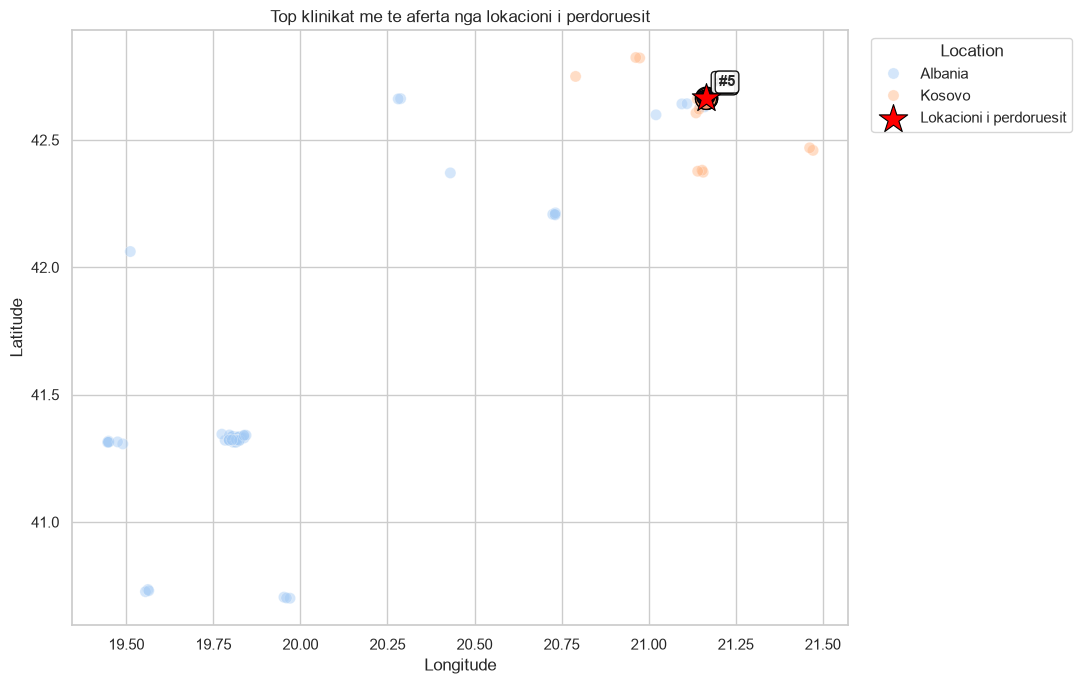

,name,location,reviews_average,distance_km
0,Bonsai Clinic,Albania,4.9,0.081724
1,DermaD,Albania,3.9,0.175880
2,EEV Group,Kosovo,5.0,0.213451
3,Hana Dermatology Estetic,Kosovo,4.9,0.675581
4,ECHO MED Qendra Diagnostike Terapeutike,Kosovo,4.9,0.692318


In [14]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=clinic_df,
    x="longitude",
    y="latitude",
    hue="location",
    palette="pastel",
    s=65,
    alpha=0.45,
    edgecolor="white",
    linewidth=0.4,
)

sns.scatterplot(
    data=nearest_clinics,
    x="longitude",
    y="latitude",
    hue="distance_km",
    size="distance_km",
    sizes=(260, 100),
    palette="rocket_r",
    edgecolor="black",
    linewidth=0.9,
    legend=False,
)

plt.scatter(
    USER_LONGITUDE,
    USER_LATITUDE,
    marker="*",
    s=460,
    color="red",
    edgecolor="black",
    linewidth=0.8,
    label="Lokacioni i perdoruesit",
    zorder=5,
)

for rank, row in nearest_clinics.iterrows():
    plt.annotate(
        f"#{rank + 1}",
        xy=(row["longitude"], row["latitude"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.9),
    )

plt.title("Top klinikat me te aferta nga lokacioni i perdoruesit")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(nearest_clinics[["name", "location", "reviews_average", "distance_km"]])


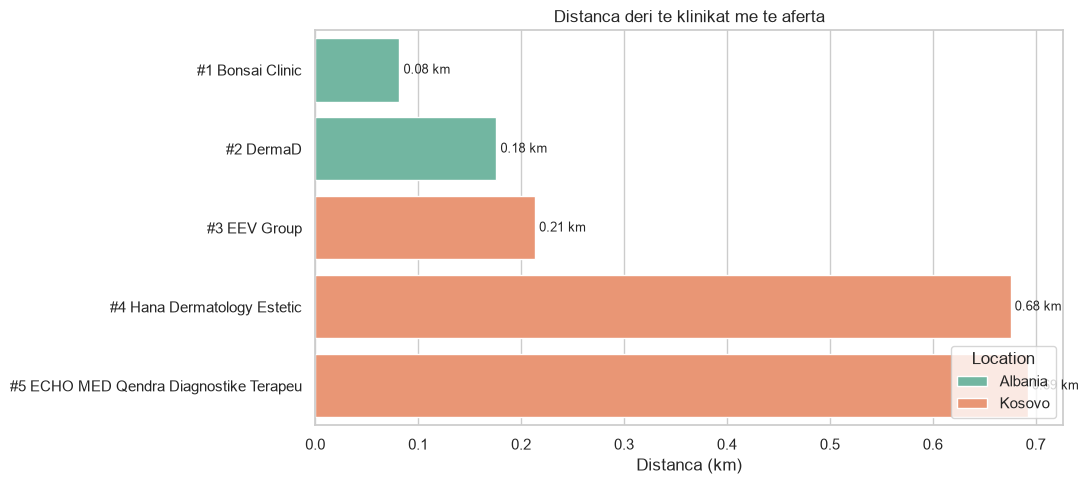

In [15]:
plot_df = nearest_clinics.sort_values("distance_km", ascending=True).copy()
plot_df["label"] = [f"#{i + 1} {name[:35]}" for i, name in enumerate(plot_df["name"])]

plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    y="label",
    x="distance_km",
    hue="location" if "location" in plot_df.columns else None,
    dodge=False,
    palette="Set2",
)

plt.title("Distanca deri te klinikat me te aferta")
plt.xlabel("Distanca (km)")
plt.ylabel("")
plt.legend(title="Location", loc="lower right")

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f km", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


### 12. Rekomandimi Final

In [16]:
best_clinic = nearest_clinics.iloc[0]

print("Klinika me e afert e parashikuar nga KNN:")
print(f"Emri: {best_clinic['name']}")
print(f"Adresa: {best_clinic['address']}")
print(f"Telefoni: {best_clinic['phone_number']}")
print(f"Website: {best_clinic['website']}")
print(f"Vleresimi mesatar: {best_clinic['reviews_average']}")
print(f"Distanca: {best_clinic['distance_km']:.3f} km")

Klinika me e afert e parashikuar nga KNN:
Emri: Bonsai Clinic
Adresa: 22 Rruga Bajram Kelmendi, Prishtinë 10000
Telefoni: +383 49 288 433
Website: Nuk ka website
Vleresimi mesatar: 4.9
Distanca: 0.082 km


### 13. Vleresimi me Confusion Matrix

Modeli kryesor perdor `NearestNeighbors`, prandaj nuk ka etiketa reale train/test si klasifikimi klasik. Per te matur saktesine, krijojme pika testuese sintetike afer cdo klinike dhe trajnojme nje `KNeighborsClassifier` qe parashikon `clinic_id`. Kjo tregon sa mire logjika KNN e ndan zonen rreth seciles klinike.


Accuracy ne test set sintetik: 0.9237 (92.37%)
Numri i mostrave ne test set: 930
Numri i klinikave: 124


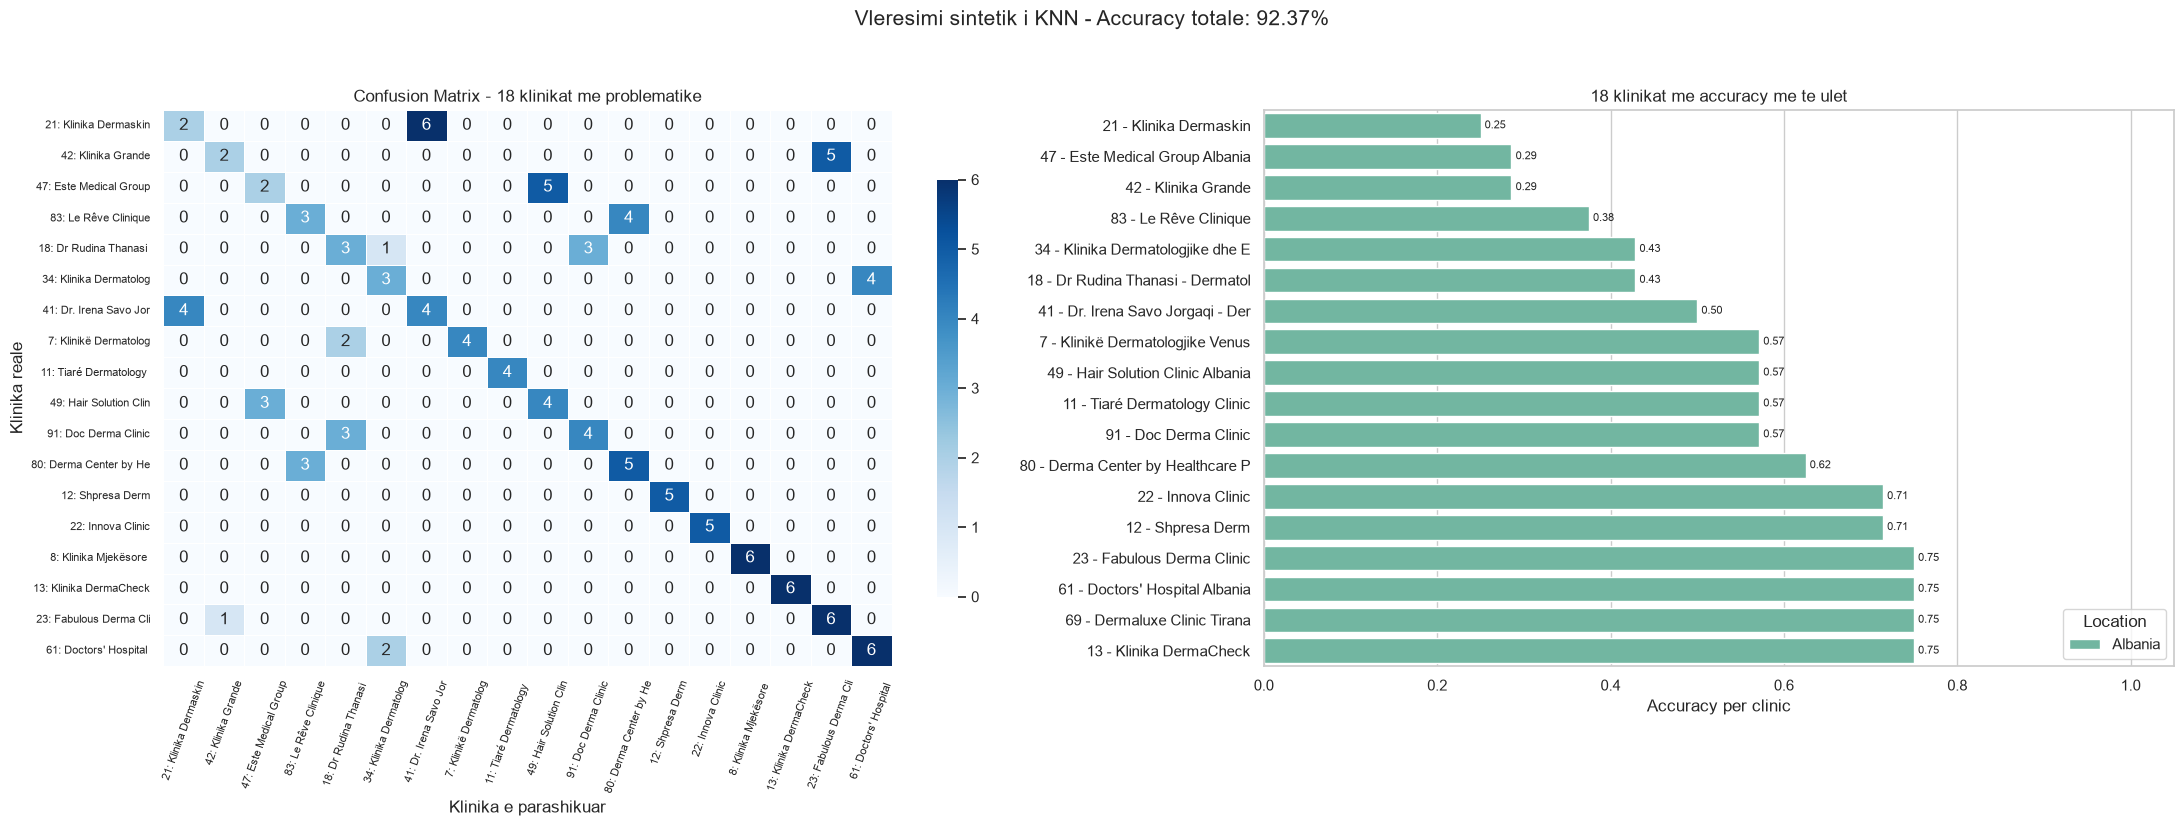


Klinikat me me shume gabime:


,clinic_id,clinic_name,location,correct,incorrect,total,clinic_accuracy
21,21,Klinika Dermaskin,Albania,2,6,8,0.250000
42,42,Klinika Grande,Albania,2,5,7,0.285714
47,47,Este Medical Group Albania,Albania,2,5,7,0.285714
83,83,Le Rêve Clinique,Albania,3,5,8,0.375000
18,18,Dr Rudina Thanasi - Dermatolog - Venerolog,Albania,3,4,7,0.428571
34,34,Klinika Dermatologjike dhe Estetike “Ermira Vasili”,Albania,3,4,7,0.428571
41,41,"Dr. Irena Savo Jorgaqi - Dermatologe, Specialiste e Mjekesise Estetike",Albania,4,4,8,0.500000
7,7,Klinikë Dermatologjike Venus,Albania,4,3,7,0.571429
11,11,Tiaré Dermatology Clinic,Albania,4,3,7,0.571429
49,49,Hair Solution Clinic Albania,Albania,4,3,7,0.571429


In [17]:
rng = np.random.default_rng(42)
samples_per_clinic = 30
coordinate_noise = 0.00035

synthetic_rows = []
for _, clinic in clinic_df.iterrows():
    lat_samples = rng.normal(clinic["latitude"], coordinate_noise, samples_per_clinic)
    lon_samples = rng.normal(clinic["longitude"], coordinate_noise, samples_per_clinic)

    for lat, lon in zip(lat_samples, lon_samples):
        synthetic_rows.append({
            "latitude": lat,
            "longitude": lon,
            "clinic_id": clinic["clinic_id"],
        })

eval_df = pd.DataFrame(synthetic_rows)
X_eval = np.radians(eval_df[["latitude", "longitude"]].to_numpy())
y_eval = eval_df["clinic_id"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_eval,
    y_eval,
    test_size=0.25,
    random_state=42,
    stratify=y_eval,
)

classifier_model = KNeighborsClassifier(
    n_neighbors=3,
    algorithm="ball_tree",
    metric="haversine",
)
classifier_model.fit(X_train, y_train)
y_pred = classifier_model.predict(X_test)

labels = clinic_df["clinic_id"].to_numpy()
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=labels)

print(f"Accuracy ne test set sintetik: {accuracy:.4f} ({accuracy:.2%})")
print(f"Numri i mostrave ne test set: {len(y_test)}")
print(f"Numri i klinikave: {len(labels)}")

summary_df = pd.DataFrame({
    "clinic_id": labels,
    "clinic_name": clinic_df["name"].to_numpy(),
    "location": clinic_df["location"].to_numpy(),
    "correct": np.diag(cm),
    "total": cm.sum(axis=1),
})
summary_df["incorrect"] = summary_df["total"] - summary_df["correct"]
summary_df["clinic_accuracy"] = summary_df["correct"] / summary_df["total"]

focus_df = summary_df.sort_values(["incorrect", "clinic_accuracy"], ascending=[False, True]).head(18)
focus_ids = focus_df["clinic_id"].to_numpy()
focus_positions = [int(np.where(labels == clinic_id)[0][0]) for clinic_id in focus_ids]
cm_focus = cm[np.ix_(focus_positions, focus_positions)]
focus_labels = [f"{cid}: {name[:18]}" for cid, name in zip(focus_df["clinic_id"], focus_df["clinic_name"])]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(
    cm_focus,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    xticklabels=focus_labels,
    yticklabels=focus_labels,
    cbar_kws={"shrink": 0.75},
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix - 18 klinikat me problematike")
axes[0].set_xlabel("Klinika e parashikuar")
axes[0].set_ylabel("Klinika reale")
axes[0].tick_params(axis="x", rotation=70, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

accuracy_plot_df = summary_df.sort_values("clinic_accuracy").head(18).copy()
accuracy_plot_df["label"] = accuracy_plot_df["clinic_id"].astype(str) + " - " + accuracy_plot_df["clinic_name"].str.slice(0, 28)
sns.barplot(
    data=accuracy_plot_df,
    x="clinic_accuracy",
    y="label",
    hue="location",
    dodge=False,
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("18 klinikat me accuracy me te ulet")
axes[1].set_xlabel("Accuracy per clinic")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.05)
axes[1].legend(title="Location", loc="lower right")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3, fontsize=8)

plt.suptitle(f"Vleresimi sintetik i KNN - Accuracy totale: {accuracy:.2%}", fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

print("\nKlinikat me me shume gabime:")
display(
    summary_df.sort_values(["incorrect", "clinic_accuracy"], ascending=[False, True])
    .head(15)[["clinic_id", "clinic_name", "location", "correct", "incorrect", "total", "clinic_accuracy"]]
)


### 14. Ruajtja e Modelit dhe Datasetit te Pastruar

In [18]:
joblib.dump(knn_model, MODEL_PATH)
joblib.dump(clinic_df, DATA_CLEAN_PATH)

print(f"Modeli u ruajt ne: {MODEL_PATH}")
print(f"Dataseti i pastruar u ruajt ne: {DATA_CLEAN_PATH}")

Modeli u ruajt ne: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset\clinic_knn_2_model.pkl
Dataseti i pastruar u ruajt ne: c:\Users\vesav\Desktop\DermaScan\clinics\clinic_dataset\clinic_knn_2_clean_data.pkl
